In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


sys.path.append('../')
from src_experiment.paths import outputs
from src_experiment.estimate_quantities import ExperimentEvaluator

In [2]:
# Define path
def get_path(noise, architecture, seed):
    return outputs / F"wbc_label_noise/n{noise}_{architecture}/seed_{int(seed)}.h5"

get_path(0.0, "[5,5,5]", seed=101)

PosixPath('/home/johan/Documents/phd/WP1/geometric_binning_estimator/outputs/wbc_label_noise/n0.0_[5,5,5]/seed_101.h5')

In [3]:

def get_mean_MI(noise, architecture, seeds=[101,102,103,104,105]):
    # Should return the Mi for all epochs for all paths, and the average across all paths
    MIs = {}
    for seed in seeds:
        path = get_path(noise, architecture, seed)
        ev = ExperimentEvaluator(path)
        df_results = ev.evaluate_all()
        MIs["epoch"] = df_results["epoch"].values if "epoch" not in MIs else MIs["epoch"]
        MIs["layer_idx"] = df_results["layer_idx"].values if "layer_idx" not in MIs else MIs["layer_idx"]
        MIs[f"I(Y;W)_seed_{seed}"] = df_results["I(Y;W)"].values
        MIs[f"I(X;W)_seed_{seed}"] = df_results["I(X;W)"].values
    # Now calculate the mean across seeds for each epoch and layer
    MI_mean = {}
    MIs["I(Y;W)_mean"] = np.mean([MIs[f"I(Y;W)_seed_{seed}"] for seed in seeds], axis=0)
    MIs["I(X;W)_mean"] = np.mean([MIs[f"I(X;W)_seed_{seed}"] for seed in seeds], axis=0)
    MI_mean["epoch"] = MIs["epoch"]
    MI_mean["layer_idx"] = MIs["layer_idx"]
    MI_mean["I(Y;W)"] = MIs["I(Y;W)_mean"]
    MI_mean["I(X;W)"] = MIs["I(X;W)_mean"]
    return pd.DataFrame(MIs), pd.DataFrame(MI_mean)

In [4]:

full_df, mean_df = get_mean_MI(0.0, "[5, 5, 5]")

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

In [5]:
full_df

,epoch,layer_idx,I(Y;W)_seed_101,I(X;W)_seed_101,I(Y;W)_seed_102,I(X;W)_seed_102,I(Y;W)_seed_103,I(X;W)_seed_103,I(Y;W)_seed_104,I(X;W)_seed_104,I(Y;W)_seed_105,I(X;W)_seed_105,I(Y;W)_mean,I(X;W)_mean
0,0,1,0.408690,2.310098,0.195730,1.595611,0.195245,2.011019,0.279179,1.460391,0.629995,1.871487,0.341768,1.849721
1,0,2,0.458296,2.665063,0.203170,1.669470,0.318709,3.343347,0.378507,2.177268,0.716194,3.591958,0.414975,2.689421
2,0,3,0.486345,3.417007,0.203170,1.669470,0.390190,4.129746,0.378507,2.177268,0.734981,3.628289,0.438639,3.004356
3,0,4,0.509596,3.676116,0.203170,1.669470,0.428169,4.308076,0.397294,2.213598,0.745027,3.680921,0.456651,3.109636
4,1,1,0.374153,2.288400,0.195730,1.595611,0.155576,1.838267,0.279179,1.460391,0.540220,1.966290,0.308972,1.829792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,140,4,0.852446,4.021850,0.797953,3.394688,0.845065,4.253116,0.871981,3.045743,0.907044,3.278551,0.854898,3.598789
84,150,1,0.410879,2.000714,0.439538,2.126441,0.330505,2.156857,0.240419,1.207792,0.607486,2.714377,0.405765,2.041236
85,150,2,0.822927,3.177270,0.471273,2.252973,0.445138,3.044602,0.751441,2.359916,0.767166,3.124899,0.651589,2.791932
86,150,3,0.822927,3.669871,0.702021,3.241910,0.765297,3.830797,0.778657,2.743871,0.767166,3.226163,0.767214,3.342523


In [23]:
import pandas as pd

# Define the lists of what you want to plot
architectures = ["[5, 5, 5]", "[15, 15, 15]", "[50, 50, 50]"] # Replace with your actual architecture names
noise_levels = [0.0, 0.2, 0.4]

all_data = []

# Loop through every combination of architecture and noise
for arch in architectures:
    for noise in noise_levels:
        
        # Call your function. We use [1] to grab the MI_mean dataframe
        df_mean = get_mean_MI(noise, arch)[1].copy()
        
        # INJECT THE MISSING METADATA COLUMNS HERE
        df_mean['architecture'] = arch
        df_mean['label_noise'] = noise 
        
        # Append to our master list
        all_data.append(df_mean)

# Combine everything into one massive DataFrame
combined_df = pd.concat(all_data, ignore_index=True)

# Filter for just the first 3 layers (optional, but recommended for clarity)
unique_layers = sorted(combined_df['layer_idx'].unique())
layers_to_keep = unique_layers[:3]
combined_df = combined_df[combined_df['layer_idx'].isin(layers_to_keep)]

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

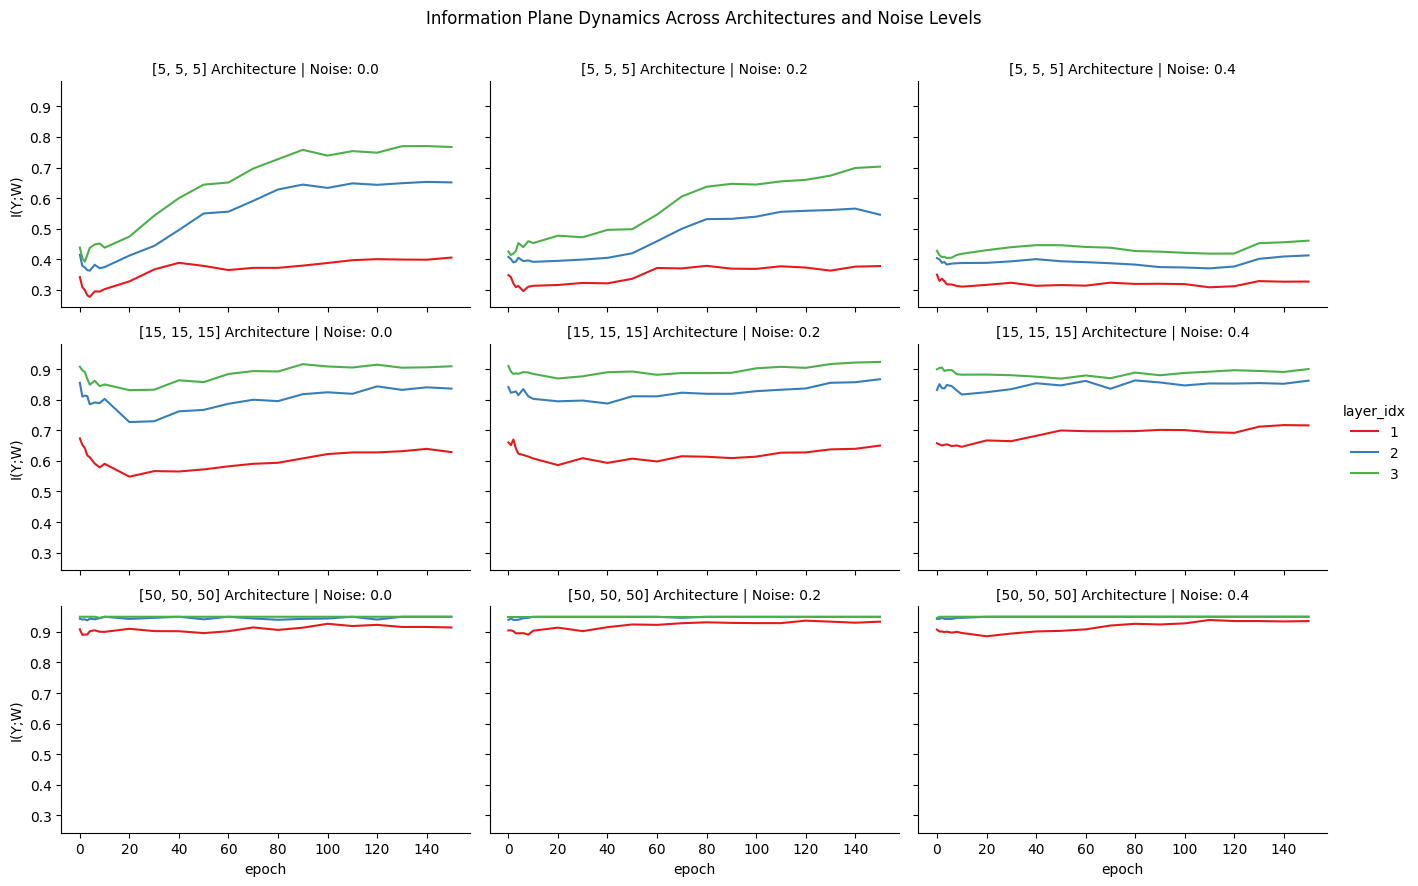

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'combined_df' has all your data for all architectures, noises, and layers

g = sns.relplot(
    data=combined_df,
    x="epoch",
    y="I(Y;W)",
    hue="layer_idx",       # Different colors for layers
    col="label_noise",     # Different columns for noise levels
    row="architecture",    # Different rows for architectures
    kind="line",
    palette="Set1",
    height=3,              # Height of each individual subplot
    aspect=1.5             # Width-to-height ratio of each subplot
)

# Clean up the titles
g.set_titles(row_template="{row_name} Architecture", col_template="Noise: {col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Information Plane Dynamics Across Architectures and Noise Levels")

plt.show()

In [41]:
from scipy.stats import entropy
path = get_path(0.0, "[5, 5, 5]", 101)
ev = ExperimentEvaluator(path)
df_results = ev.evaluate_all()


# 1. Calculate H(X) bound (Data Entropy / Max Memorization)
# Since every point is assumed uniform, H(X) = log2(N)
H_X = np.log2(ev.N_total)

# 2. Calculate H(Y) bound (Label Entropy / Max Prediction)
# Find the distribution of your classes
_, counts = np.unique(ev.labels, return_counts=True)
probabilities = counts / counts.sum()
H_Y = entropy(probabilities, base=2)

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

In [43]:
print(f"H(X): {H_X:.2f}")
print(f"H(Y): {H_Y:.2f}")


H(X): 6.83
H(Y): 0.95


Running grid search for d_x = 2...
Running grid search for d_x = 5...
Running grid search for d_x = 10...
Running grid search for d_x = 20...
Running grid search for d_x = 150...
Running grid search for d_x = 500...


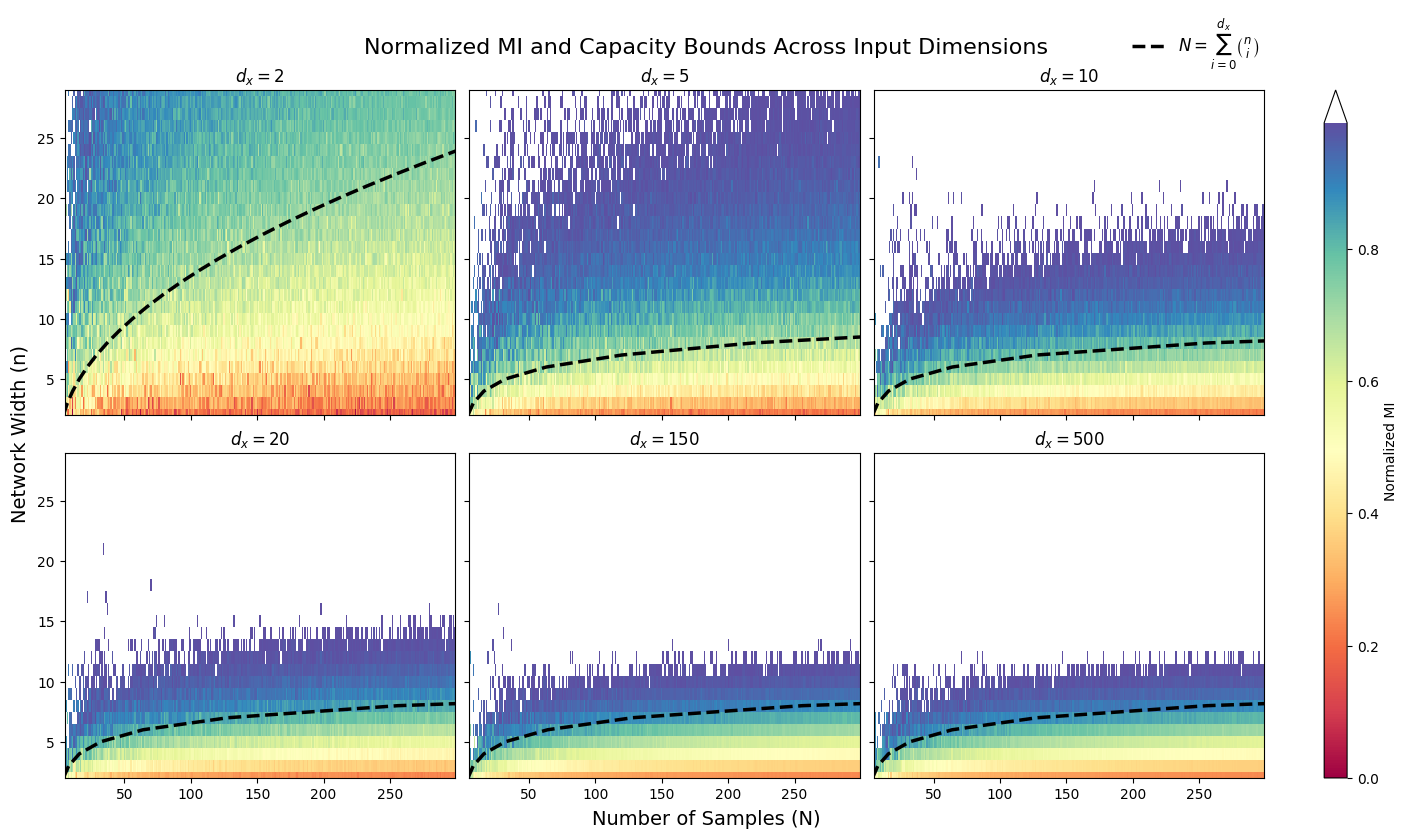

In [91]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def get_normalized_mi(X, model):
    """
    Passes data X through a single-layer network to get activation patterns,
    and calculates the normalized Mutual Information I(X;T) / H(X).
    """
    with torch.no_grad():
        Z = model(X)
        T = (Z > 0).int().numpy()
        
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    N = X.shape[0]
    H_X = np.log2(N)
    
    return H_T / H_X if H_X > 0 else 0.0

def run_experiment_1(dx=2, ax=None):
    d_x = dx  
    N_values = np.arange(5, 300, 1)        
    dn_values = np.arange(2, 30, 1)        
    
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Running grid search for d_x = {d_x}...")
    
    for i, d_n in enumerate(dn_values):
        for j, N in enumerate(N_values):
            X = torch.randn(N, d_x)
            layer = nn.Linear(d_x, d_n)
            mi_matrix[i, j] = get_normalized_mi(X, layer)
            
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    X_mesh, Y_mesh = np.meshgrid(N_values, dn_values)
    
    cmap = plt.colormaps['Spectral'].copy() 
    cmap.set_over('white') 
    
    cp = ax.pcolormesh(
        X_mesh, 
        Y_mesh, 
        mi_matrix, 
        shading='auto', 
        cmap=cmap, 
        vmin=0.0, 
        vmax=0.99
    )
    
    N_bound = []
    for n in dn_values:
        bound = sum(math.comb(n, i) for i in range(min(n + 1, d_x + 1)))
        N_bound.append(bound)
        
    ax.plot(
        N_bound, 
        dn_values, 
        color='black', 
        linestyle='--', 
        linewidth=2.5, 
        label=r'$N = \sum_{i=0}^{d_x} \binom{n}{i}$'
    )
    
    ax.set_xlim(N_values.min(), N_values.max())
    ax.set_ylim(dn_values.min(), dn_values.max())
    
    # Set a cleaner, smaller title for each subplot
    ax.set_title(f'$d_x={d_x}$')
    
    # Return the colormap object so the main script can build a global colorbar
    return cp

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    dx_values = [2, 5, 10, 20, 150, 500]  
    
    # Added sharex, sharey, and constrained layout
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, layout="constrained")
    axes_flat = axes.flatten()

    # Store the colormap from the last run
    cp = None
    for ax, dx in zip(axes_flat, dx_values): 
        cp = run_experiment_1(dx=dx, ax=ax)
        
    # --- GLOBAL STYLING ---
    
    # 1. Single Global Axis Labels
    fig.supxlabel('Number of Samples (N)', fontsize=14)
    fig.supylabel('Network Width (n)', fontsize=14)
    fig.suptitle('Normalized MI and Capacity Bounds Across Input Dimensions', fontsize=16)

    # 2. Single Global Colorbar spanning the axes
    # We pass ax=axes so Matplotlib knows to scale it alongside the grid
    cbar = fig.colorbar(cp, ax=axes, label='Normalized MI', extend='max', aspect=30)

    # 3. Single Global Legend
    # Extract the line handle and label from the first subplot to avoid duplicates
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.85, 1.04), frameon=False, fontsize=12)

    plt.show()

In [93]:
class TrackingMLP(nn.Module):
    """An MLP that returns the concatenated activation pattern of ALL layers."""
    def __init__(self, d_in, d_n, L):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(d_in, d_n))
        for _ in range(L - 1):
            self.layers.append(nn.Linear(d_n, d_n))
            
    def forward(self, x):
        patterns = []
        out = x
        for i, layer in enumerate(self.layers):
            # Pre-activation
            out = layer(out)
            
            # Record the binary pattern for this specific layer
            patterns.append((out > 0).int().numpy())
            
            # Apply ReLU for all but the final layer
            if i < len(self.layers) - 1:
                out = torch.relu(out)
                
        # Concatenate horizontally: a point's region is defined by ALL layers combined
        global_pattern = np.concatenate(patterns, axis=1)
        return global_pattern

def get_normalized_mi_deep(X, model):
    """Updated to work directly with the concatenated global patterns."""
    with torch.no_grad():
        # The model now directly outputs the full Nx(L*d_n) binary matrix
        T = model(X)
        
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    N = X.shape[0]
    H_X = np.log2(N)
    
    return H_T / H_X if H_X > 0 else 0.0

Running grid search for d_x = 2, L = 3...
Running grid search for d_x = 5, L = 3...
Running grid search for d_x = 10, L = 3...
Running grid search for d_x = 20, L = 3...
Running grid search for d_x = 150, L = 3...
Running grid search for d_x = 500, L = 3...


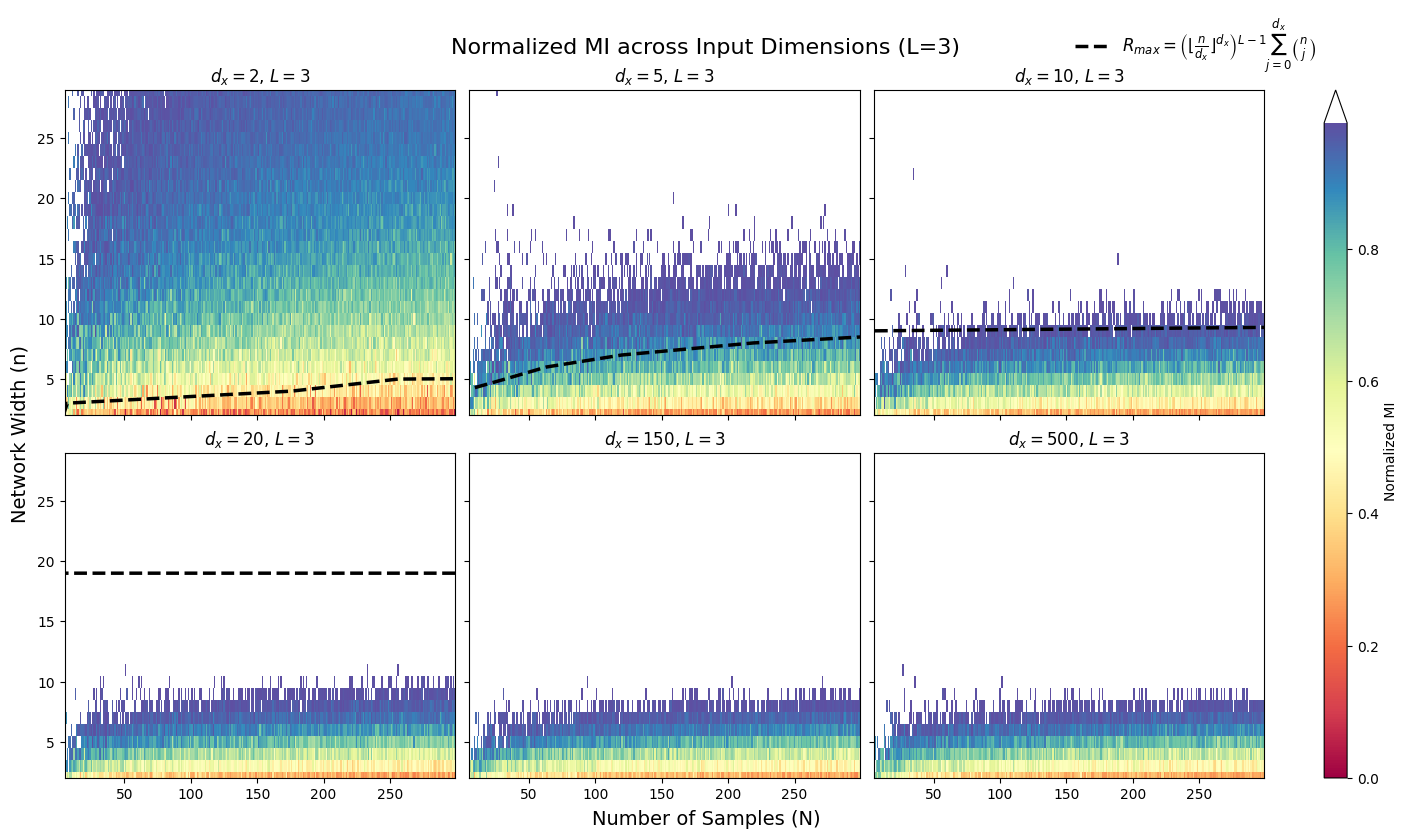

In [94]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def get_normalized_mi(X, model):
    """
    Passes data X through a network to get activation patterns of the FINAL layer,
    and calculates the normalized Mutual Information I(X;T) / H(X).
    """
    with torch.no_grad():
        Z = model(X)
        T = (Z > 0).int().numpy()
        
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    N = X.shape[0]
    H_X = np.log2(N)
    
    return H_T / H_X if H_X > 0 else 0.0

def create_mlp(d_in, d_n, L):
    """Creates an MLP with L linear layers of width d_n, separated by ReLUs."""
    if L == 1:
        return nn.Linear(d_in, d_n)
    
    modules = [nn.Linear(d_in, d_n), nn.ReLU()]
    for _ in range(L - 2):
        modules.append(nn.Linear(d_n, d_n))
        modules.append(nn.ReLU())
    modules.append(nn.Linear(d_n, d_n)) # Final pre-activations
    
    return nn.Sequential(*modules)

def run_experiment_1(dx=2, L=2, ax=None):
    d_x = dx  
    N_values = np.arange(5, 300, 1)        
    dn_values = np.arange(2, 30, 1)        
    
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Running grid search for d_x = {d_x}, L = {L}...")
    
    for i, d_n in enumerate(dn_values):
        for j, N in enumerate(N_values):
            X = torch.randn(N, d_x)
            model = TrackingMLP(d_x, d_n, L)
            mi_matrix[i, j] = get_normalized_mi_deep(X, model)
            
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    X_mesh, Y_mesh = np.meshgrid(N_values, dn_values)
    
    cmap = plt.colormaps['Spectral'].copy() 
    cmap.set_over('white') 
    
    cp = ax.pcolormesh(
        X_mesh, 
        Y_mesh, 
        mi_matrix, 
        shading='auto', 
        cmap=cmap, 
        vmin=0.0, 
        vmax=0.99
    )
    
    # --- UPDATED THEORETICAL BOUNDARY LOGIC ---
    N_bound = []
    for n in dn_values:
        # 1. The summation part (Schläfli sum for the final layer)
        sum_part = sum(math.comb(n, j) for j in range(min(n + 1, d_x + 1)))
        
        # 2. The exponential depth multiplier for L > 1
        if L > 1:
            multiplier = (math.floor(n / d_x) ** d_x) ** (L - 1)
        else:
            multiplier = 1 # Reverts to standard single-layer formula
            
        bound = multiplier * sum_part
        N_bound.append(bound)
        
    # Dynamically format the label string based on the number of layers
    if L > 1:
        label_str = r'$R_{max} = \left(\lfloor \frac{n}{d_x} \rfloor^{d_x}\right)^{L-1} \sum_{j=0}^{d_x} \binom{n}{j}$'
    else:
        label_str = r'$R_{max} = \sum_{j=0}^{d_x} \binom{n}{j}$'
        
    ax.plot(
        N_bound, 
        dn_values, 
        color='black', 
        linestyle='--', 
        linewidth=2.5, 
        label=label_str
    )
    
    ax.set_xlim(N_values.min(), N_values.max())
    ax.set_ylim(dn_values.min(), dn_values.max())
    ax.set_title(f'$d_x={d_x}$, $L={L}$')
    
    return cp

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    dx_values = [2, 5, 10, 20, 150, 500]  
    L_val = 3 # Let's test it with a 3-layer network
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, layout="constrained")
    axes_flat = axes.flatten()

    cp = None
    for ax, dx in zip(axes_flat, dx_values): 
        # Pass L into the experiment
        cp = run_experiment_1(dx=dx, L=L_val, ax=ax)
        
    fig.supxlabel('Number of Samples (N)', fontsize=14)
    fig.supylabel('Network Width (n)', fontsize=14)
    
    # Updated global title
    fig.suptitle(f'Normalized MI across Input Dimensions (L={L_val})', fontsize=16)

    cbar = fig.colorbar(cp, ax=axes, label='Normalized MI', extend='max', aspect=30)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.85, 1.04), frameon=False, fontsize=12)

    plt.show()

Running grid search for d_x = 2, L = 5...
Running grid search for d_x = 5, L = 5...
Running grid search for d_x = 10, L = 5...
Running grid search for d_x = 20, L = 5...
Running grid search for d_x = 150, L = 5...
Running grid search for d_x = 500, L = 5...


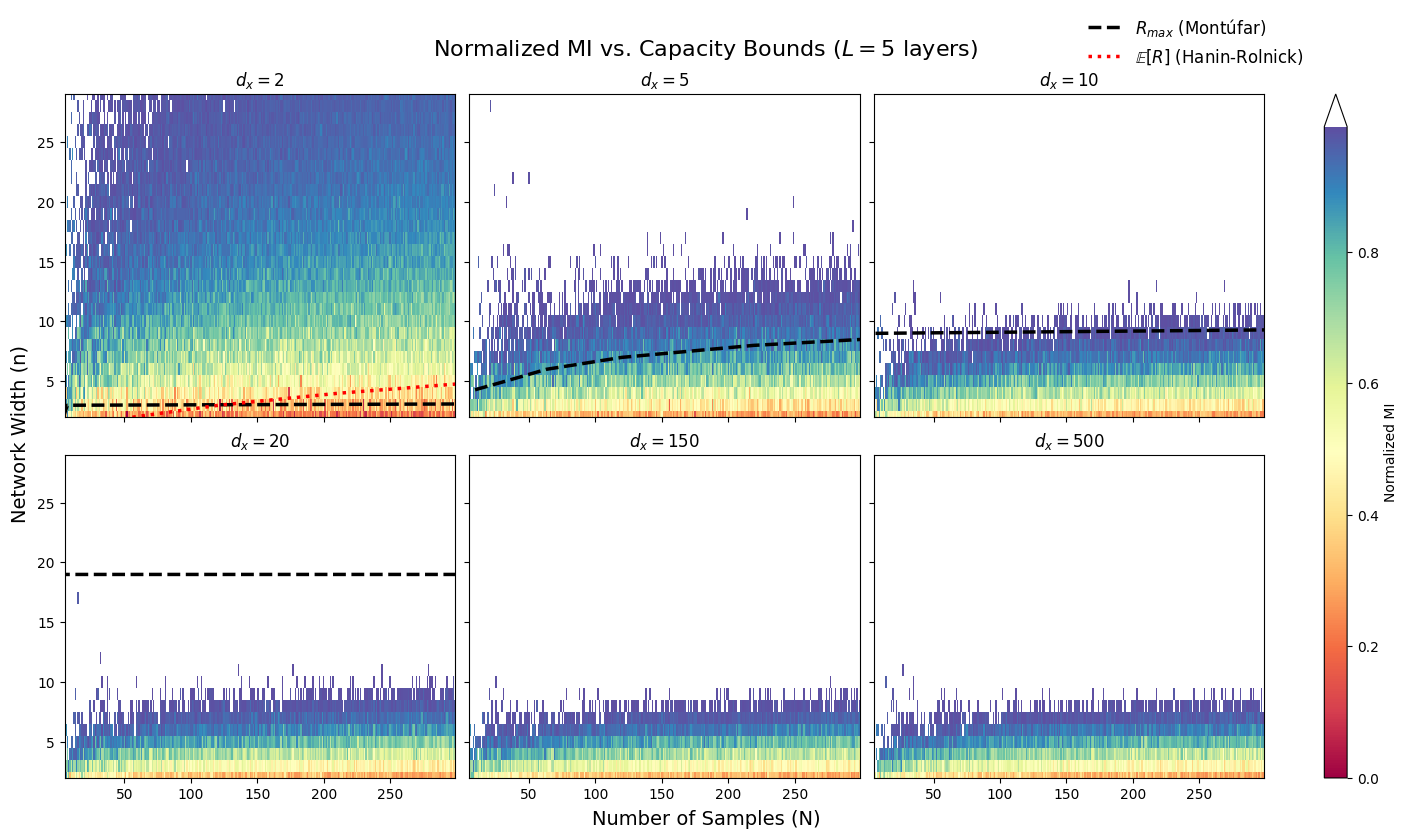

In [ ]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

class TrackingMLP(nn.Module):
    """An MLP that returns the concatenated activation pattern of ALL layers."""
    def __init__(self, d_in, d_n, L):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(d_in, d_n))
        for _ in range(L - 1):
            self.layers.append(nn.Linear(d_n, d_n))
            
    def forward(self, x):
        patterns = []
        out = x
        for i, layer in enumerate(self.layers):
            out = layer(out)
            # Record the binary pattern for this specific layer
            patterns.append((out > 0).int())
            
            # Apply ReLU for all but the final layer
            if i < len(self.layers) - 1:
                out = torch.relu(out)
                
        # Concatenate horizontally and convert to numpy
        return torch.cat(patterns, dim=1).numpy()

def get_normalized_mi_deep(X, model):
    """Calculates MI using the concatenated global patterns from all layers."""
    with torch.no_grad():
        T = model(X)
        
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    N = X.shape[0]
    H_X = np.log2(N)
    
    return H_T / H_X if H_X > 0 else 0.0

def run_experiment_1(dx=2, L=2, ax=None):
    d_x = dx  
    N_values = np.arange(5, 300, 1)        
    dn_values = np.arange(2, 30, 1)        
    
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Running grid search for d_x = {d_x}, L = {L}...")
    
    for i, d_n in enumerate(dn_values):
        for j, N in enumerate(N_values):
            X = torch.randn(N, d_x)
            model = TrackingMLP(d_x, d_n, L)
            mi_matrix[i, j] = get_normalized_mi_deep(X, model)
            
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    X_mesh, Y_mesh = np.meshgrid(N_values, dn_values)
    
    cmap = plt.colormaps['Spectral'].copy() 
    cmap.set_over('white') 
    
    cp = ax.pcolormesh(
        X_mesh, 
        Y_mesh, 
        mi_matrix, 
        shading='auto', 
        cmap=cmap, 
        vmin=0.0, 
        vmax=0.99
    )
    
    # --- CALCULATE BOUNDARIES ---
    N_bound_max = []
    N_bound_expected = []
    
    for n in dn_values:
        # 1. Montúfar Maximum Bound (R_max)
        sum_part = sum(math.comb(n, j) for j in range(min(n + 1, d_x + 1)))
        multiplier = (math.floor(n / d_x) ** d_x) ** (L - 1) if L > 1 else 1
        N_bound_max.append(multiplier * sum_part)
        
        # 2. Hanin-Rolnick Expected Bound (E[R])
        N_total = L * n
        expected_bound = sum(math.comb(N_total, i) for i in range(min(N_total + 1, d_x + 1)))
        N_bound_expected.append(expected_bound)
        
    # --- PLOT BOUNDARIES ---
    
    # R_max (Theoretical Maximum - Black Dashed)
    label_max = r'$R_{max}$ (Montúfar)' if L > 1 else r'$R_{max} = \sum_{j=0}^{d_x} \binom{n}{j}$'
    ax.plot(N_bound_max, dn_values, color='black', linestyle='--', linewidth=2.5, label=label_max)
    
    # E[R] (Expected - Red Dotted)
    ax.plot(N_bound_expected, dn_values, color='red', linestyle=':', linewidth=2.5, label=r'$\mathbb{E}[R]$ (Hanin-Rolnick)')
    
    ax.set_xlim(N_values.min(), N_values.max())
    ax.set_ylim(dn_values.min(), dn_values.max())
    ax.set_title(f'$d_x={d_x}$')
    
    return cp

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    dx_values = [2, 5, 10, 20, 150, 500]  
    L_val = 5 
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, layout="constrained")
    axes_flat = axes.flatten()

    cp = None
    for ax, dx in zip(axes_flat, dx_values): 
        cp = run_experiment_1(dx=dx, L=L_val, ax=ax)
        
    fig.supxlabel('Number of Samples (N)', fontsize=14)
    fig.supylabel('Network Width (n)', fontsize=14)
    fig.suptitle(f'Normalized MI vs. Capacity Bounds ($L={L_val}$ layers)', fontsize=16)

    cbar = fig.colorbar(cp, ax=axes, label='Normalized MI', extend='max', aspect=30)

    # Extract handles for the global legend
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.85, 1.04), frameon=False, fontsize=12)

    plt.show()

Processing Grid: d_x=200, L=5...
Experiments complete. Generating combined plot...


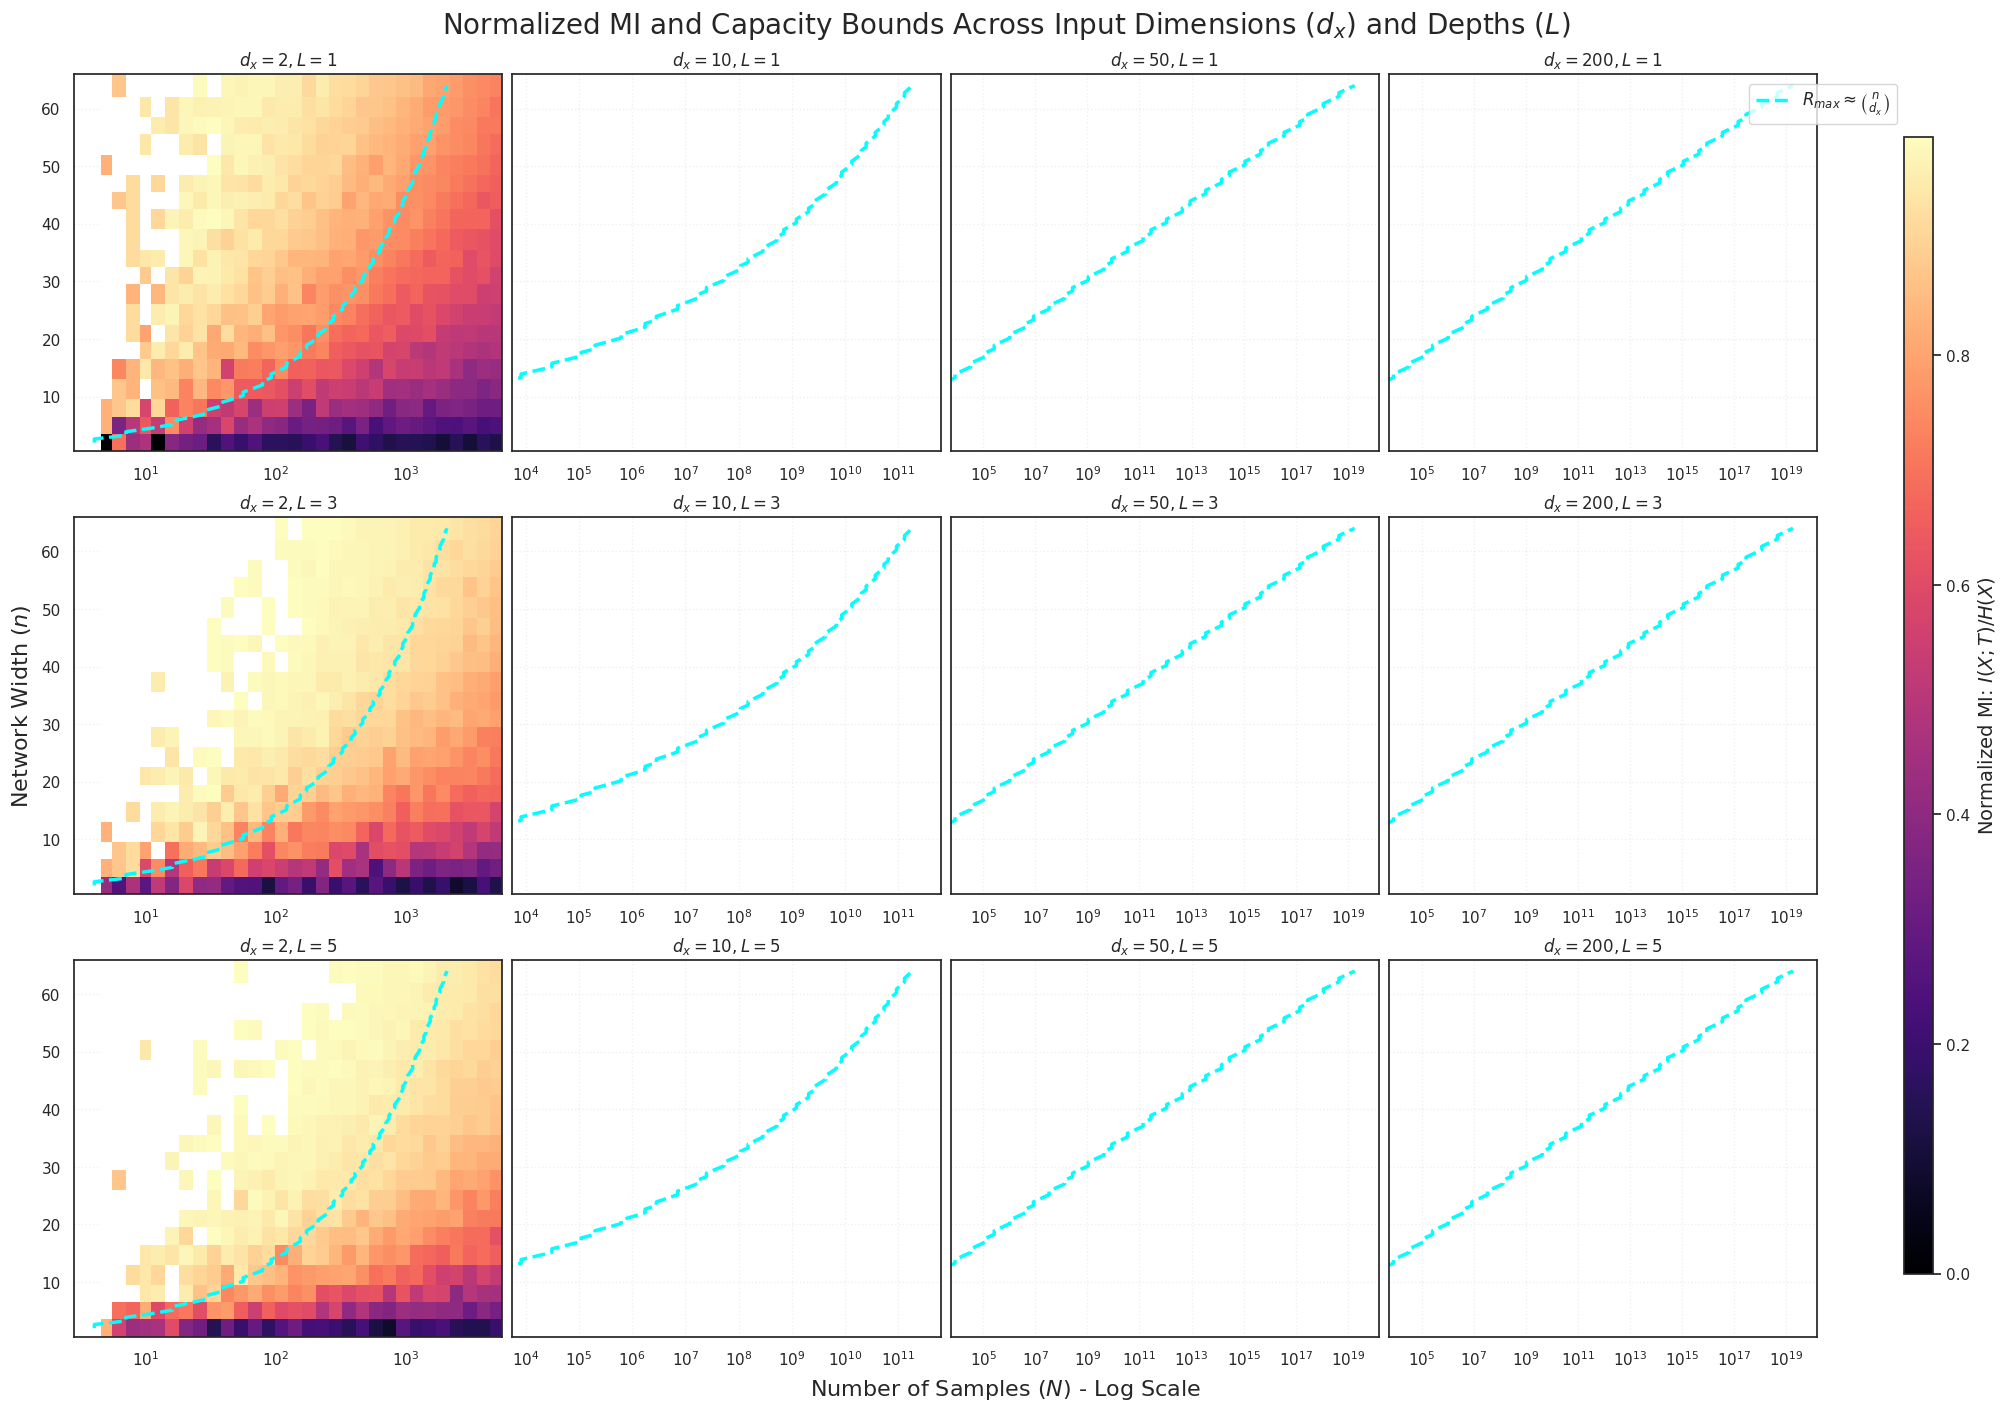

In [33]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

# --- SEABORN STYLING ---
sns.set_theme(style="white", palette="muted")

# --- 1. MODEL DEFINITION ---
class TrackingMLP(nn.Module):
    """An MLP that returns the concatenated activation pattern of ALL layers."""
    def __init__(self, d_in, d_n, L):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(d_in, d_n))
        for _ in range(L - 1):
            self.layers.append(nn.Linear(d_n, d_n))
            
    def forward(self, x):
        patterns = []
        out = x
        for i, layer in enumerate(self.layers):
            out = layer(out)
            # Record the binary pattern for this specific layer
            patterns.append((out > 0).int())
            
            # Apply ReLU for all but the final layer
            if i < len(self.layers) - 1:
                out = torch.relu(out)
                
        # Concatenate horizontally and convert to numpy
        return torch.cat(patterns, dim=1).numpy()

# --- 2. INFORMATION METRIC ---
def get_normalized_mi(X, model):
    """Calculates normalized MI using concatenated global patterns."""
    with torch.no_grad():
        T = model(X)
        
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    N = X.shape[0]
    H_X = np.log2(N)
    
    return H_T / H_X if H_X > 0 else 0.0

# --- 3. EXPERIMENT RUNNER ---
def run_experiment_grid(dx, L, ax, n_steps=20):
    # Using logspace for N to cover exponential bounds effectively
    # Covering from memorization (N=5) to far beyond capacity (N=5000)
    N_values = np.unique(np.logspace(np.log10(5), np.log10(5000), n_steps + 10).astype(int))
    # Increasing width range and steps
    dn_values = np.linspace(2, 64, n_steps).astype(int)
    
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Processing Grid: d_x={dx}, L={L}...", end='\r')
    
    for i, d_n in enumerate(dn_values):
        for j, N in enumerate(N_values):
            X = torch.randn(N, dx)
            model = TrackingMLP(dx, d_n, L)
            mi_matrix[i, j] = get_normalized_mi(X, model)
            
    # Meshgrid for pcolormesh
    X_mesh, Y_mesh = np.meshgrid(N_values, dn_values)
    
    # Colormap: rocket or magma provide a nice Seaborn alternative to Spectral
    # that highlights the high-information region (Memorization Zone) well.
    cmap = plt.colormaps['magma'].copy() 
    cmap.set_over('white') 
    
    # cp = ax.pcolormesh(X_mesh, Y_mesh, mi_matrix, shading='gouraud', cmap=cmap, vmin=0.0, vmax=1.0)
    # cp = ax.pcolormesh(X_mesh, Y_mesh, mi_matrix, shading='nearest', cmap=cmap, vmin=0.0, vmax=1.0)
    cp = ax.pcolormesh(X_mesh, Y_mesh, mi_matrix, shading='auto', cmap=cmap, vmin=0.0, vmax=0.99)
    
    # --- CAPACITY BOUNDARY ---
    n_plot = np.linspace(dn_values.min(), dn_values.max(), 100)
    N_bound = []
    
    for n in n_plot:
        # Theoretical Bound for number of regions: sum_{i=0}^{d_x} binom(n, i)
        # For multi-layer, this is the bottleneck per-layer capacity.
        # This defines the "cliff" where patterns are forced to overlap.
        bound = sum(math.comb(int(n), i) for i in range(min(int(n) + 1, dx + 1)))
        N_bound.append(bound)
        
    ax.plot(
        N_bound, 
        n_plot, 
        color='cyan', 
        linestyle='--', 
        linewidth=2.5, 
        label=r'$R_{max} \approx \binom{n}{d_x}$'
    )
    
    # Set log scale for N to visualize exponential capacity
    ax.set_xscale('log') 
    
    ax.set_title(f'$d_x={dx}, L={L}$', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.3)
    
    return cp

# --- 4. MAIN EXECUTION ---
if __name__ == "__main__":
    # Parameters for the large comparison grid
    # Input Dimensions to test
    dx_values = [2, 10, 50, 200]
    # Depths (Layers) to compare
    layers = [1, 3, 5]
    
    # Create the grid layout (Rows = Depth, Cols = Dimension)
    fig, axes = plt.subplots(len(layers), len(dx_values), figsize=(20, 14), sharey=True, constrained_layout=True)
    
    # Flatten axes for easier iteration
    axes_flat = axes.flatten() if len(layers) > 1 else [axes]

    cp = None
    subplot_idx = 0
    for l_val in layers:
        for dx_val in dx_values:
            ax = axes_flat[subplot_idx]
            # Increase n_steps here (e.g., to 25 or 30) for a smoother grid,
            # but it will significantly increase computation time.
            cp = run_experiment_grid(dx=dx_val, L=l_val, ax=ax, n_steps=20)
            subplot_idx += 1
            
    print("\nExperiments complete. Generating combined plot...")
            
    # --- GLOBAL STYLING ---
    fig.supxlabel('Number of Samples ($N$) - Log Scale', fontsize=16)
    fig.supylabel('Network Width ($n$)', fontsize=16)
    fig.suptitle('Normalized MI and Capacity Bounds Across Input Dimensions ($d_x$) and Depths ($L$)', fontsize=20)

    # Colorbar spanning the right side
    cbar = fig.colorbar(cp, ax=axes, location='right', aspect=40, shrink=0.9)
    cbar.set_label('Normalized MI: $I(X;T)/H(X)$', fontsize=14)

    # Single Legend, extracted from the first subplot
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.95, 0.95), frameon=True, fontsize=12)

    plt.show()

Running Experiment: dx=2, L=1...
Running Experiment: dx=2, L=4...


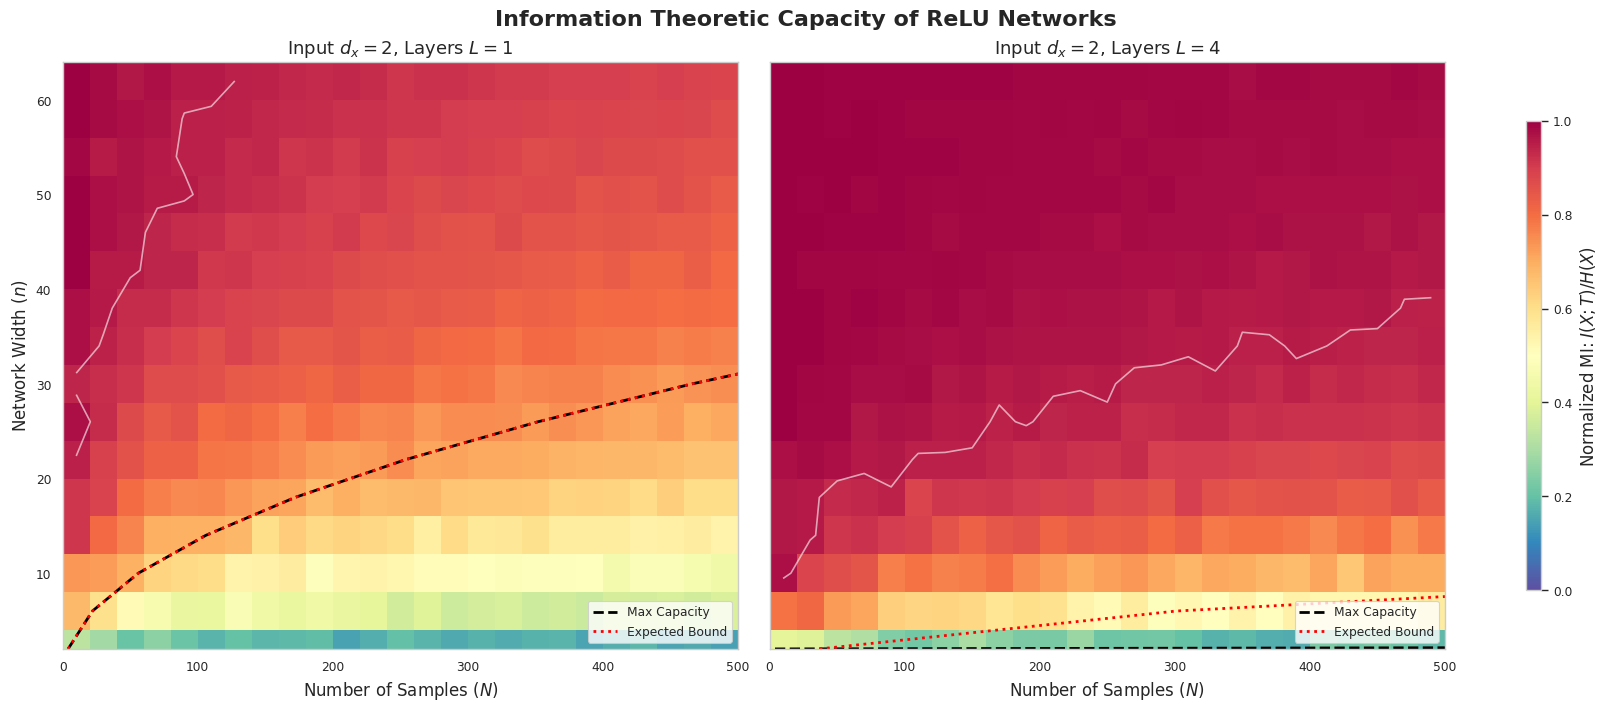

In [34]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from tqdm import tqdm # Optional: for a progress bar

# --- STYLING ---
sns.set_theme(style="whitegrid", context="paper")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. MODEL DEFINITION ---
class TrackingMLP(nn.Module):
    """An MLP that returns concatenated activation patterns of ALL layers."""
    def __init__(self, d_in, d_n, L):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(d_in, d_n))
        for _ in range(L - 1):
            self.layers.append(nn.Linear(d_n, d_n))
            
    def forward(self, x):
        patterns = []
        out = x
        for i, layer in enumerate(self.layers):
            out = layer(out)
            patterns.append((out > 0).int())
            if i < len(self.layers) - 1:
                out = torch.relu(out)
        return torch.cat(patterns, dim=1)

# --- 2. OPTIMIZED METRIC ---
def get_normalized_mi(N, dx, dn, L, n_reps=5):
    """Calculates averaged Normalized MI over multiple random initializations."""
    mi_samples = []
    
    for _ in range(n_reps):
        X = torch.randn(N, dx).to(device)
        model = TrackingMLP(dx, dn, L).to(device)
        
        with torch.no_grad():
            T = model(X).cpu().numpy()
            
        # Unique patterns define the entropy of the representation
        _, counts = np.unique(T, axis=0, return_counts=True)
        probs = counts / np.sum(counts)
        H_T = entropy(probs, base=2)
        H_X = np.log2(N)
        
        mi_samples.append(H_T / H_X if H_X > 0 else 0.0)
        
    return np.mean(mi_samples)

# --- 3. THEORETICAL BOUNDS ---
def get_bounds(dn_values, dx, L):
    """Calculates Montúfar (Max) and Hanin-Rolnick (Expected) bounds."""
    r_max = []
    e_r = []
    for n in dn_values:
        # Montúfar Max
        sum_part = sum(math.comb(int(n), i) for i in range(min(int(n) + 1, dx + 1)))
        mult = (max(1, math.floor(int(n) / dx)) ** dx) ** (L - 1) if L > 1 else 1
        r_max.append(mult * sum_part)
        
        # Hanin-Rolnick Expected
        n_total = L * int(n)
        e_r.append(sum(math.comb(n_total, i) for i in range(min(n_total + 1, dx + 1))))
        
    return r_max, e_r

# --- 4. EXPERIMENT EXECUTION ---
def run_experiment(dx, L, ax, N_max=600, n_max=50, n_reps=3):
    N_values = np.arange(10, N_max + 10, 20)
    dn_values = np.arange(2, n_max + 2, 4)
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Running Experiment: dx={dx}, L={L}...")
    for i, dn in enumerate(dn_values):
        for j, N in enumerate(N_values):
            mi_matrix[i, j] = get_normalized_mi(N, dx, dn, L, n_reps=n_reps)
            
    X, Y = np.meshgrid(N_values, dn_values)
    cp = ax.pcolormesh(X, Y, mi_matrix, shading='auto', cmap='Spectral_r', vmin=0, vmax=1)
    
    # Plot Boundaries
    r_max, e_r = get_bounds(dn_values, dx, L)
    ax.plot(r_max, dn_values, color='black', lw=2, ls='--', label='Max Capacity')
    ax.plot(e_r, dn_values, color='red', lw=2, ls=':', label='Expected Bound')
    
    # Add a 95% MI Contour (where memorization effectively stops)
    ax.contour(X, Y, mi_matrix, levels=[0.95], colors='white', alpha=0.6)
    
    ax.set_title(f"Input $d_x={dx}$, Layers $L={L}$", fontsize=13)
    ax.set_xlim(0, N_max)
    ax.set_ylim(dn_values.min(), n_max)
    return cp

if __name__ == "__main__":
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True, constrained_layout=True)
    
    # Plot 1: Standard low-dim single layer
    cp1 = run_experiment(dx=2, L=1, ax=ax1, N_max=500, n_max=64, n_reps=5)
    ax1.set_ylabel("Network Width ($n$)", fontsize=12)
    ax1.set_xlabel("Number of Samples ($N$)", fontsize=12)
    ax1.legend(loc='lower right', frameon=True)

    # Plot 2: Deeper network with same dimension
    cp2 = run_experiment(dx=2, L=4, ax=ax2, N_max=500, n_max=64, n_reps=5)
    ax2.set_xlabel("Number of Samples ($N$)", fontsize=12)
    ax2.legend(loc='lower right', frameon=True)

    # Global Colorbar
    cbar = fig.colorbar(cp2, ax=[ax1, ax2], location='right', aspect=30, shrink=0.8)
    cbar.set_label("Normalized MI: $I(X;T) / H(X)$", fontsize=12)

    fig.suptitle("Information Theoretic Capacity of ReLU Networks", fontsize=16, fontweight='bold')
    plt.show()

Running grid: Input Dim (dx)=2, Layers (L)=1...
Running grid: Input Dim (dx)=10, Layers (L)=1...
Running grid: Input Dim (dx)=2, Layers (L)=3...
Running grid: Input Dim (dx)=10, Layers (L)=3...


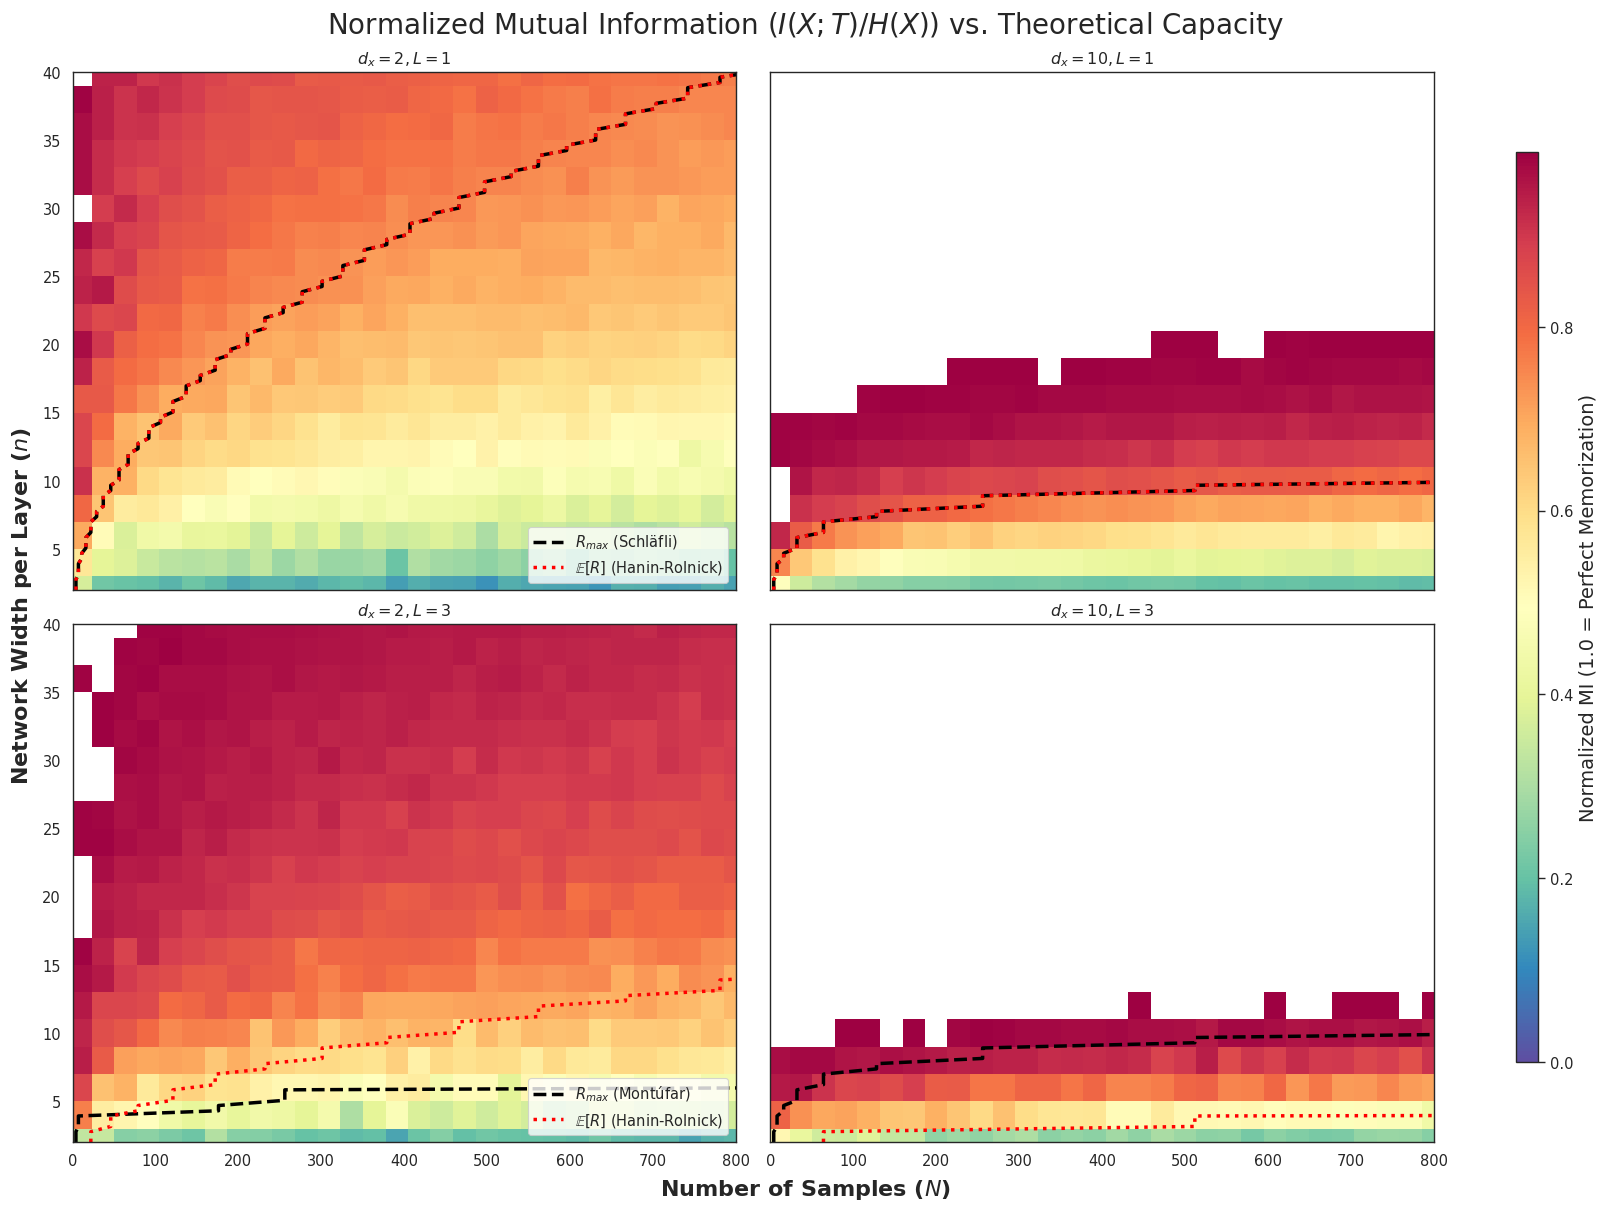

In [38]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

# --- 1. CONFIGURATION & STYLING ---
# Professional academic styling
sns.set_theme(style="white", context="paper", font_scale=1.2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. MODEL DEFINITION ---
class TrackingMLP(nn.Module):
    """An MLP that captures binary activation patterns across ALL hidden layers."""
    def __init__(self, d_in, d_n, L):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d_in, d_n)])
        for _ in range(L - 1):
            self.layers.append(nn.Linear(d_n, d_n))
            
    def forward(self, x):
        patterns = []
        out = x
        for i, layer in enumerate(self.layers):
            out = layer(out)
            # Threshold at 0 to get the binary pattern (1 for active, 0 for inactive)
            patterns.append((out > 0).int())
            if i < len(self.layers) - 1:
                out = torch.relu(out)
        # Concatenate horizontally: a region is defined by the full network state
        return torch.cat(patterns, dim=1)

# --- 3. METRICS (WITH MONTE CARLO SMOOTHING) ---
def get_smoothed_mi(N, dx, dn, L, n_reps=4):
    """Calculates Normalized MI, averaged over multiple random initializations."""
    mi_estimates = []
    
    for _ in range(n_reps):
        # Push data and model to GPU if available for faster forward passes
        X = torch.randn(N, dx, device=device)
        model = TrackingMLP(dx, dn, L).to(device)
        
        with torch.no_grad():
            T = model(X).cpu().numpy()
            
        # Count unique patterns to find activation entropy H(T)
        _, counts = np.unique(T, axis=0, return_counts=True)
        probs = counts / np.sum(counts)
        H_T = entropy(probs, base=2)
        
        # H(X) bound: Maximum possible entropy if every sample gets a unique pattern
        H_X = np.log2(N)
        mi_estimates.append(H_T / H_X if H_X > 0 else 0.0)
        
    return np.mean(mi_estimates)

# --- 4. EXPERIMENT ROUTINE ---
def run_grid_experiment(dx, L, ax):
    # Setup grid resolutions
    N_max, n_max = 800, 40
    N_vals = np.linspace(10, N_max, 30).astype(int)
    dn_vals = np.linspace(2, n_max, 20).astype(int)
    
    mi_matrix = np.zeros((len(dn_vals), len(N_vals)))
    print(f"Running grid: Input Dim (dx)={dx}, Layers (L)={L}...")
    
    for i, dn in enumerate(dn_vals):
        for j, N in enumerate(N_vals):
            mi_matrix[i, j] = get_smoothed_mi(N, dx, dn, L)
            
    X_mesh, Y_mesh = np.meshgrid(N_vals, dn_vals)
    
    # Heatmap: Spectral_r puts Red at 1.0 (Memorization) and Blue at 0.0 (Compression)
    cmap = plt.colormaps['Spectral_r'].copy()
    cmap.set_over('white')
    cp = ax.pcolormesh(X_mesh, Y_mesh, mi_matrix, shading='auto', cmap=cmap, vmin=0, vmax=0.99)
    
    # --- CALCULATE THEORETICAL BOUNDARIES ---
    n_line = np.linspace(2, n_max, 100)
    bound_max = []
    bound_exp = []
    
    for n in n_line:
        # 1. Base Schläfli Sum (Capacity of a single layer)
        base_sum = sum(math.comb(int(n), i) for i in range(min(int(n) + 1, dx + 1)))
        
        # 2. Montúfar Multiplier (The folding effect of deep layers)
        multiplier = (max(1, math.floor(int(n) / dx)) ** dx) ** (L - 1) if L > 1 else 1
        bound_max.append(multiplier * base_sum)
        
        # 3. Hanin-Rolnick Expected Bound
        N_total = L * int(n)
        bound_exp.append(sum(math.comb(N_total, i) for i in range(min(N_total + 1, dx + 1))))
        
    # Plot the boundaries
    label_max = r'$R_{max}$ (Montúfar)' if L > 1 else r'$R_{max}$ (Schläfli)'
    ax.plot(bound_max, n_line, color='black', lw=2.5, ls='--', label=label_max)
    ax.plot(bound_exp, n_line, color='red', lw=2.5, ls=':', label=r'$\mathbb{E}[R]$ (Hanin-Rolnick)')
    
    # Formatting
    ax.set_title(f'$d_x={dx}, L={L}$', fontweight='bold')
    ax.set_xlim(0, N_max)
    ax.set_ylim(2, n_max)
    ax.grid(True, linestyle=':', alpha=0.4)
    
    return cp

# --- 5. MAIN EXECUTION ---
if __name__ == "__main__":
    # A 2x2 grid is perfect for narrating the impact of Depth vs. Dimension
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True, constrained_layout=True)
    
    # Top Row: Shallow Networks (L=1)
    run_grid_experiment(dx=2, L=1, ax=axes[0, 0])
    run_grid_experiment(dx=10, L=1, ax=axes[0, 1])
    
    # Bottom Row: Deep Networks (L=3)
    run_grid_experiment(dx=2, L=3, ax=axes[1, 0])
    cp_final = run_grid_experiment(dx=10, L=3, ax=axes[1, 1])
    
    # --- GLOBAL LABELS & LEGENDS ---
    fig.supxlabel('Number of Samples ($N$)', fontsize=16, fontweight='bold')
    fig.supylabel('Network Width per Layer ($n$)', fontsize=16, fontweight='bold')
    fig.suptitle('Normalized Mutual Information ($I(X;T)/H(X)$) vs. Theoretical Capacity', fontsize=20)
    
    # Add legends to the left-most plots
    axes[0, 0].legend(loc='lower right', frameon=True)
    axes[1, 0].legend(loc='lower right', frameon=True)
    
    # Single unified colorbar spanning the right side
    cbar = fig.colorbar(cp_final, ax=axes, location='right', aspect=40, shrink=0.85)
    cbar.set_label('Normalized MI (1.0 = Perfect Memorization)', fontsize=14)

    plt.show()
    

Running grid: d_x=2, L=1 (Points: 50x20)...
Running grid: d_x=10, L=1 (Points: 50x20)...
Running grid: d_x=50, L=1 (Points: 50x20)...
Running grid: d_x=100, L=1 (Points: 50x20)...
Running grid: d_x=2, L=2 (Points: 50x20)...
Running grid: d_x=10, L=2 (Points: 50x20)...
Running grid: d_x=50, L=2 (Points: 50x20)...
Running grid: d_x=100, L=2 (Points: 50x20)...
Running grid: d_x=2, L=5 (Points: 50x20)...
Running grid: d_x=10, L=5 (Points: 50x20)...
Running grid: d_x=50, L=5 (Points: 50x20)...
Running grid: d_x=100, L=5 (Points: 50x20)...
Running grid: d_x=2, L=7 (Points: 50x20)...
Running grid: d_x=10, L=7 (Points: 50x20)...
Running grid: d_x=50, L=7 (Points: 50x20)...
Running grid: d_x=100, L=7 (Points: 50x20)...


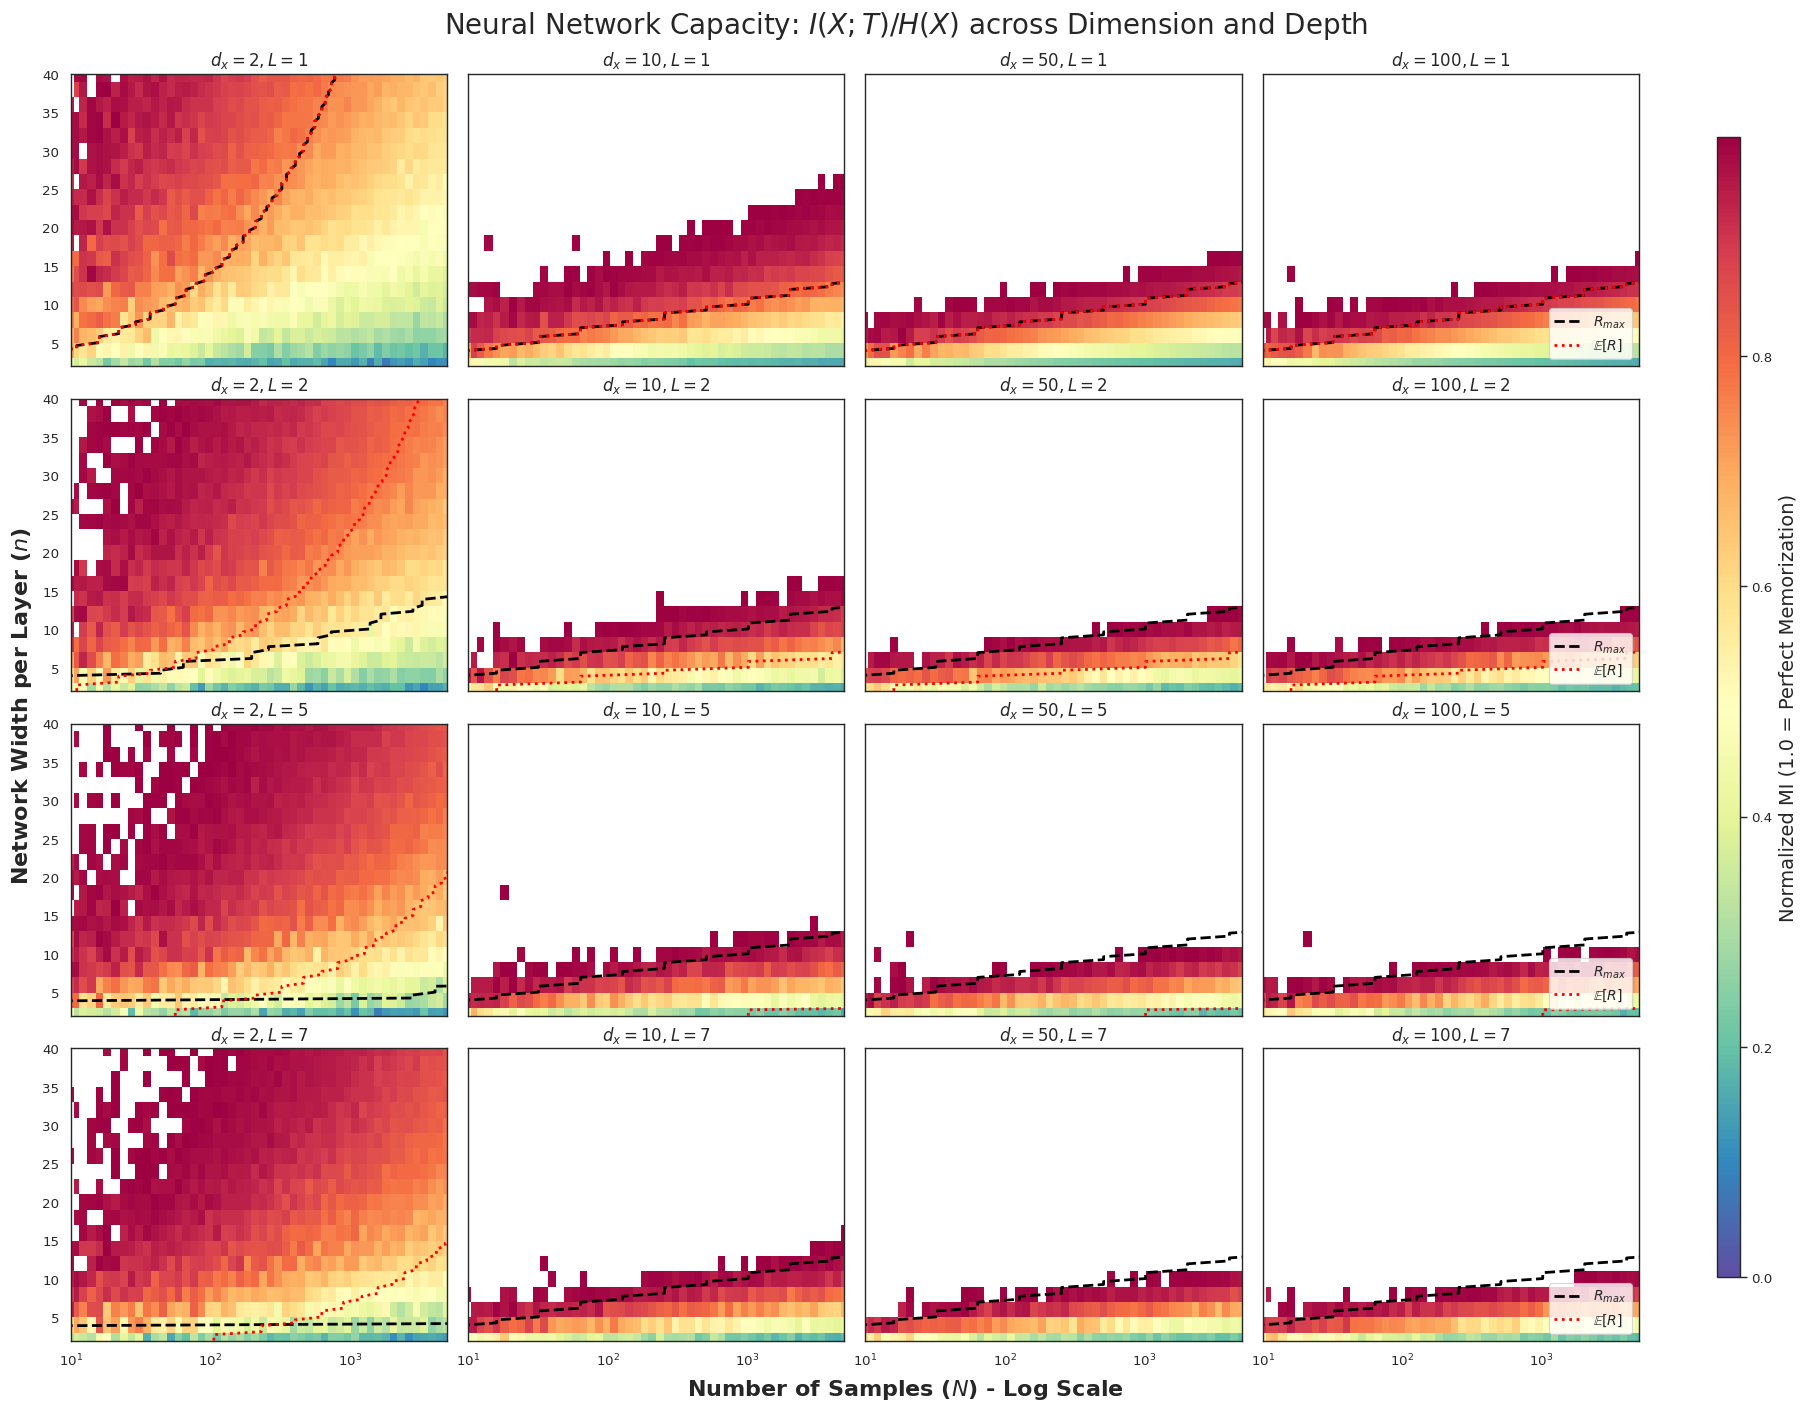

In [40]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

# --- 1. CONFIGURATION & STYLING ---
sns.set_theme(style="white", context="paper", font_scale=1.1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. MODEL DEFINITION ---
class TrackingMLP(nn.Module):
    """An MLP that captures binary activation patterns across ALL hidden layers."""
    def __init__(self, d_in, d_n, L):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d_in, d_n)])
        for _ in range(L - 1):
            self.layers.append(nn.Linear(d_n, d_n))
            
    def forward(self, x):
        patterns = []
        out = x
        for i, layer in enumerate(self.layers):
            out = layer(out)
            # Binary pattern: 1 for active, 0 for inactive
            patterns.append((out > 0).int())
            if i < len(self.layers) - 1:
                out = torch.relu(out)
        return torch.cat(patterns, dim=1)

# --- 3. METRICS ---
def get_smoothed_mi(N, dx, dn, L, n_reps=2):
    """Calculates Normalized MI, averaged over multiple random initializations."""
    mi_estimates = []
    
    for _ in range(n_reps):
        X = torch.randn(N, dx, device=device)
        model = TrackingMLP(dx, dn, L).to(device)
        
        with torch.no_grad():
            T = model(X).cpu().numpy()
            
        _, counts = np.unique(T, axis=0, return_counts=True)
        probs = counts / np.sum(counts)
        H_T = entropy(probs, base=2)
        H_X = np.log2(N)
        
        mi_estimates.append(H_T / H_X if H_X > 0 else 0.0)
        
    return np.mean(mi_estimates)

# --- 4. EXPERIMENT ROUTINE ---
def run_grid_experiment(dx, L, ax):
    # Setup grid resolutions
    N_max, n_max = 5000, 40
    
    # Logarithmic spacing for N to capture exponential capacity curves
    # Using np.unique ensures strictly increasing integer values
    N_vals = np.unique(np.logspace(np.log10(10), np.log10(N_max), 50).astype(int))
    dn_vals = np.linspace(2, n_max, 20).astype(int)
    
    mi_matrix = np.zeros((len(dn_vals), len(N_vals)))
    print(f"Running grid: d_x={dx}, L={L} (Points: {len(N_vals)}x{len(dn_vals)})...")
    
    for i, dn in enumerate(dn_vals):
        for j, N in enumerate(N_vals):
            mi_matrix[i, j] = get_smoothed_mi(N, dx, dn, L)
            
    X_mesh, Y_mesh = np.meshgrid(N_vals, dn_vals)
    
    cmap = plt.colormaps['Spectral_r'].copy()
    cmap.set_over('white')
    
    # shading='nearest' works best for non-uniform/logarithmic coordinates
    cp = ax.pcolormesh(X_mesh, Y_mesh, mi_matrix, shading='nearest', cmap=cmap, vmin=0, vmax=0.99)
    
    # --- CALCULATE THEORETICAL BOUNDARIES ---
    n_line = np.linspace(2, n_max, 100)
    bound_max = []
    bound_exp = []
    
    for n in n_line:
        # Schläfli Sum
        base_sum = sum(math.comb(int(n), i) for i in range(min(int(n) + 1, dx + 1)))
        
        # Montúfar Multiplier
        multiplier = (max(1, math.floor(int(n) / dx)) ** dx) ** (L - 1) if L > 1 else 1
        bound_max.append(multiplier * base_sum)
        
        # Hanin-Rolnick Expected Bound
        N_total = L * int(n)
        bound_exp.append(sum(math.comb(N_total, i) for i in range(min(N_total + 1, dx + 1))))
        
    # Plot boundaries
    label_max = r'$R_{max}$'
    ax.plot(bound_max, n_line, color='black', lw=2, ls='--', label=label_max)
    ax.plot(bound_exp, n_line, color='red', lw=2, ls=':', label=r'$\mathbb{E}[R]$')
    
    # Formatting
    ax.set_xscale('log') # Explicitly set x-axis to log scale
    ax.set_title(f'$d_x={dx}, L={L}$', fontweight='bold', fontsize=12)
    ax.set_xlim(10, N_max)
    ax.set_ylim(2, n_max)
    ax.grid(True, linestyle=':', alpha=0.4, which='both') # grid for both major/minor log ticks
    
    return cp

# --- 5. MAIN EXECUTION ---
if __name__ == "__main__":
    # Define our 3x3 test matrix parameters
    dx_values = [2, 10, 50,100]  # Columns: Increasing input dimension
    L_values = [1, 2, 5, 7]     # Rows: Increasing depth
    
    fig, axes = plt.subplots(len(L_values), len(dx_values), figsize=(18, 14), 
                             sharex=True, sharey=True, constrained_layout=True)
    
    cp_final = None
    
    for row_idx, L in enumerate(L_values):
        for col_idx, dx in enumerate(dx_values):
            ax = axes[row_idx, col_idx]
            cp_final = run_grid_experiment(dx=dx, L=L, ax=ax)
            
            # Add legends only to the far-right plots to keep it clean
            if col_idx == len(dx_values) - 1:
                ax.legend(loc='lower right', frameon=True, fontsize=10)

    # --- GLOBAL LABELS & LEGENDS ---
    fig.supxlabel('Number of Samples ($N$) - Log Scale', fontsize=16, fontweight='bold')
    fig.supylabel('Network Width per Layer ($n$)', fontsize=16, fontweight='bold')
    fig.suptitle('Neural Network Capacity: $I(X;T)/H(X)$ across Dimension and Depth', fontsize=20)
    
    cbar = fig.colorbar(cp_final, ax=axes, location='right', aspect=50, shrink=0.9)
    cbar.set_label('Normalized MI (1.0 = Perfect Memorization)', fontsize=14)

    plt.show()